# **Ensemble Kalman RMLE - Demonstration of linear theory**

In [5]:
using OralQual
using LinearAlgebra
using Random
using CairoMakie
using Distributions
using ColorSchemes
include("PrettyPlots.jl")


@inline colmean(V::AbstractMatrix) = vec(mean(V, dims=2))

function _samplecov(V::AbstractMatrix)
    # computes sample covariance (column-wise)
    J = size(V, 2)
    μ = colmean(V)
    X = V .- μ
    return (X * X') / (J-1)
end

_samplecov (generic function with 1 method)

## **Problem Setup**
In this demo, we will illustrate the ability of our algorithm to perform randomized maximum likelihood estimation, and we will numerically illustrate our convergence theory. We will do so by studying the problem:

$$
\min_{\mathbf{v}\in\mathbb{R}^n} \|\mathbf{y} - \mathbf{Hv}\|_{\boldsymbol{\Gamma}^{-1}}^2,
$$

where $\mathbf{y}\in\mathbb{R}^n$, $\mathbf{v}\in\mathbb{R}^d$, $\mathbf{H}\in\mathbb{R}^{n\times d}$, and $\boldsymbol{\Gamma}\in\mathbb{R}^{n\times n}$ is a positive definite weight matrix.

In [18]:
n = 5  # observation space dimension
d = 20 # state space dimension
J = 10000 # ensemble size
prob = randomLinearProblemObj(n, d, J); # call constructor

By default, the constructor will create a linear forward operator $\mathbf{H}$ such that both $\mathrm{ker}(\mathbf{H})$ and $\mathrm{ker}\big(\mathbf{H}^\top\big)$ are non-trivial, and will draw an ensemble that has components in *both* $\mathrm{ran}\big(\mathbf{H}^\top\big)$ and $\mathrm{ker}(\mathbf{H})$ but does *not* span $\mathrm{ran}\big(\mathbf{H}^\top\big)$. This will allow us to study convergence in the $\mathbf{P}$ subspace.

## **Algorithm**
We create an instance of our algorithm, choose a desired number of iterations and run

In [19]:
obj = EKRMLEObj(prob.V0, prob.y, prob.Γ) # create EKRMLE object
iters = 100 # number of iterations
H_s(prob::randomLinearProblemObj, v::AbstractVector) = prob.H * v # forward map
EKRMLE_run!(obj, prob, H_s, iters); # run algorithm

## **Comparison in entire state space $\mathbb{R}^d$**

We now compare the ensemble mean $\mathrm{E}\big[\mathbf{v}_{\text{end}}^{(1:J)}\big]$ with the analytical solution $\mathbf{v}^\star = \big(\mathbf{H}^\top\mathbf{\Gamma}^{-1}\mathbf{H}\big)^\dagger \mathbf{H}^\top\mathbf{\Gamma}^{-1}\mathbf{y}$, and the ensemble covariance $\mathrm{Cov}\big[\mathbf{v}_\text{end}^{(1:J)}\big]$ with the pseudoinverse of the Hessian $\big(\mathbf{H}^\top\mathbf{\Gamma}^{-1}\mathbf{H}\big)^\dagger$. We have:

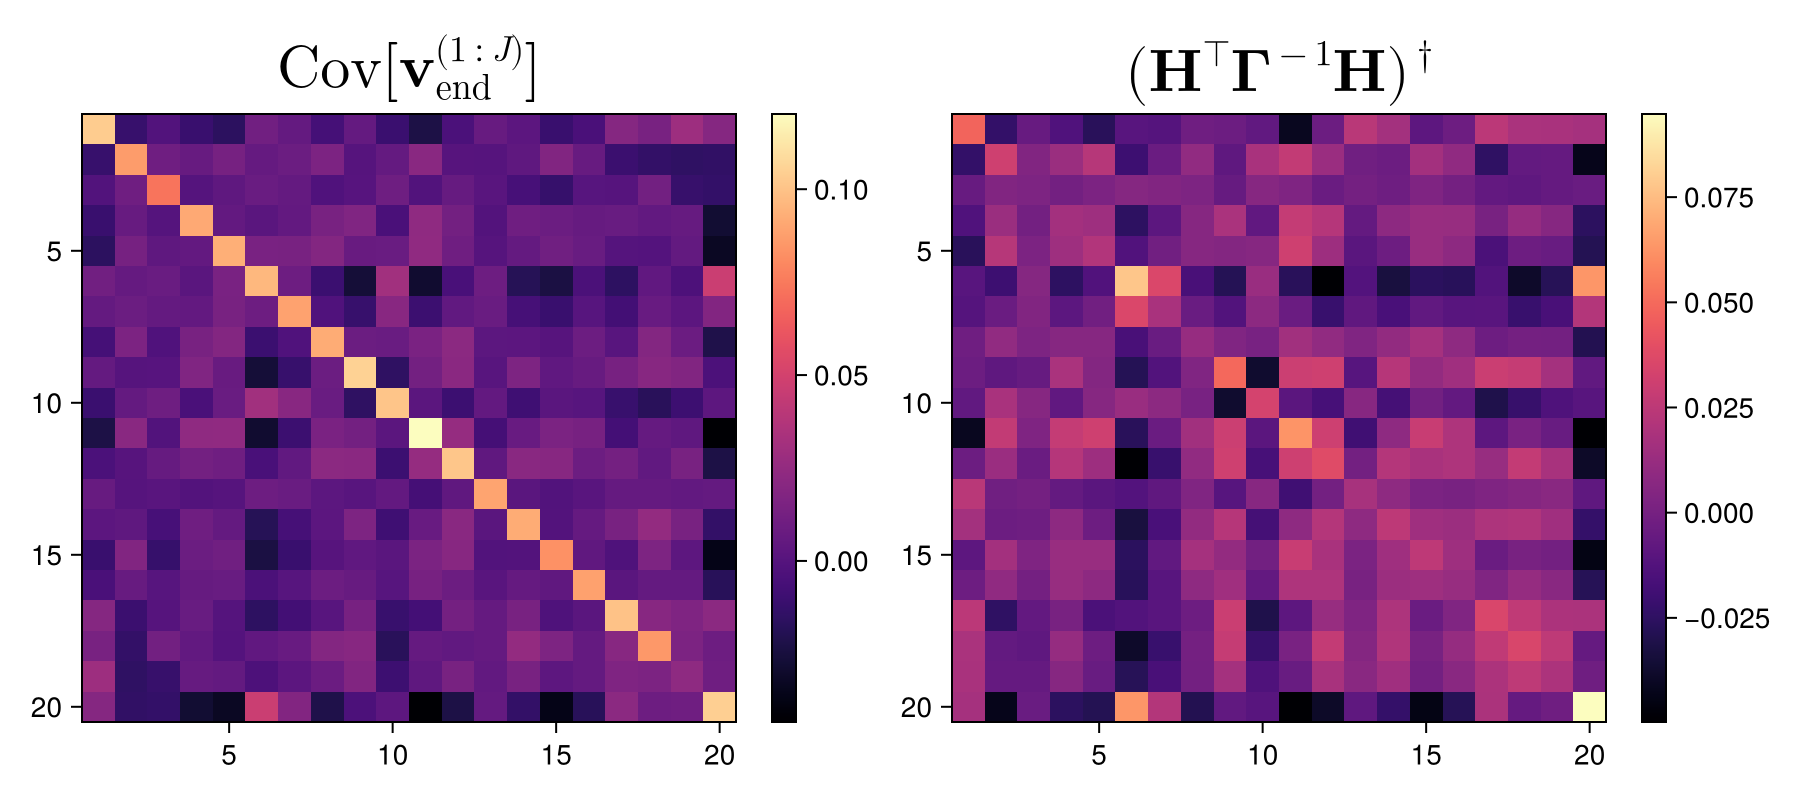

CairoMakie.Screen{IMAGE}


In [20]:
C = _samplecov(obj.V[end]) # compute ensemble covariance
μ = colmean(obj.V[end]) # compute ensemble mean

# Plot covariance
fig = Figure(size=(900,400))
ax1 = Axis(fig[1, 1], title=L"\text{Cov}[\textbf{v}_\text{end}^{(1:J)}]", titlesize=30)
ax1.yreversed=true
ax2 = Axis(fig[1, 3], title = L"(\textbf{H}^⊤\textbf{Γ}^{-1}\textbf{H})^†", titlesize=30)
ax2.yreversed=true
hm1 = heatmap!(ax1, C; colormap=:magma)
Colorbar(fig[1, 2], hm1)
hm2 = heatmap!(ax2, prob.pHess; colormap=:magma)
Colorbar(fig[1, 4], hm2)
display(fig)


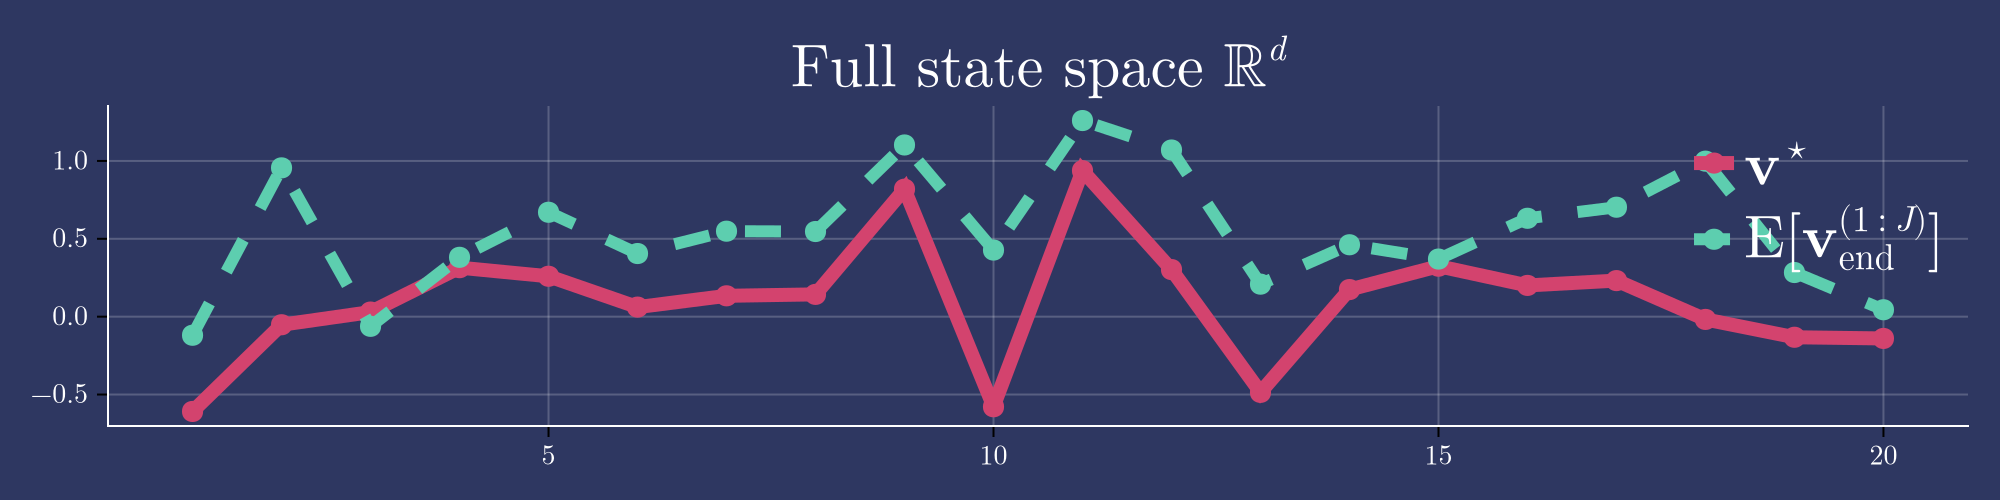

In [21]:
# Plot mean
colors = my_custom_dark_theme.palette.color[]

fig = themed_figure(; dark=true, size=(1000, 250)) do fig
    ax1 = Axis(fig[1, 1],
        title     = L"\text{Full state space }\mathbb{R}^d",
        titlesize = 30,
    )

    scatterlines!(ax1, prob.v_star;
        linewidth   = 7,
        markersize  = 15,
        label       = L"\textbf{v}^\star",
        color       = colors[2],
    )

    scatterlines!(ax1, μ;
        linewidth   = 6,
        linestyle   = :dash,
        markersize  = 15,
        label       = L"\text{E}[\textbf{v}_\text{end}^{(1:J)}]",
        color       = colors[4],
    )
    axislegend(ax1; position=:rt, framevisible=false, labelsize=30)

    fig   
end

## **Comparison in the $\mathbf{P}$ subspace**

As we can see, the quantities from the previous comaprisons do *not* match; this is due to the rank-deficient structure of our problem. To study convergence of our algorithm, we must restrict to the $\mathbf{P}$ subspace, i.e., the subspace spanned by directions observable under $\mathbf{H}$ and directions in the linear span of the ensemble. We obtain the $\mathbf{P}$ subspace as follows:

In [23]:
projectors = spectralproj(prob, _samplecov(prob.V0))
P = real.(projectors.P);

We can now compare the same quantities as above, projected onto the $\mathbf{P}$ subspace.

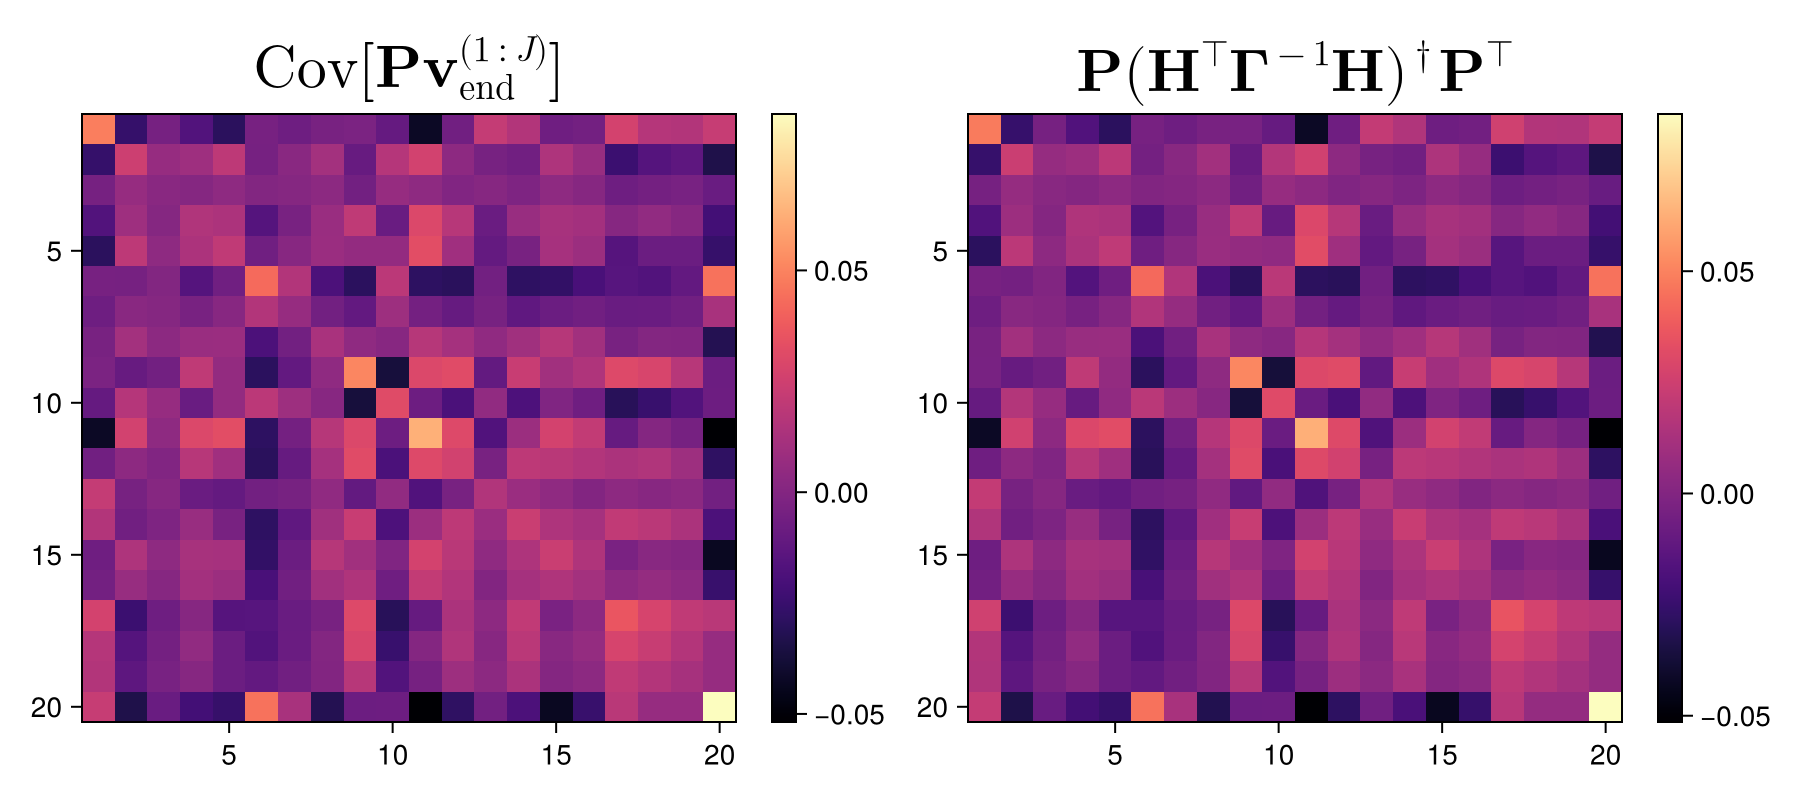

CairoMakie.Screen{IMAGE}


In [24]:
fig = Figure(size=(900,400))
ax1 = Axis(fig[1, 1], title=L"\text{Cov}[\textbf{Pv}_\text{end}^{(1:J)}]", titlesize=30)
ax1.yreversed=true
ax2 = Axis(fig[1, 3] , title = L"\textbf{P}(\textbf{H}^⊤\textbf{Γ}^{-1}\textbf{H})^†\textbf{P}^⊤", titlesize=30)
ax2.yreversed=true
hm1 = heatmap!(ax1, P*C*P'; colormap=:magma)
Colorbar(fig[1, 2], hm1)
hm2 = heatmap!(ax2, P*prob.pHess*P'; colormap=:magma)
Colorbar(fig[1, 4], hm2)
display(fig)

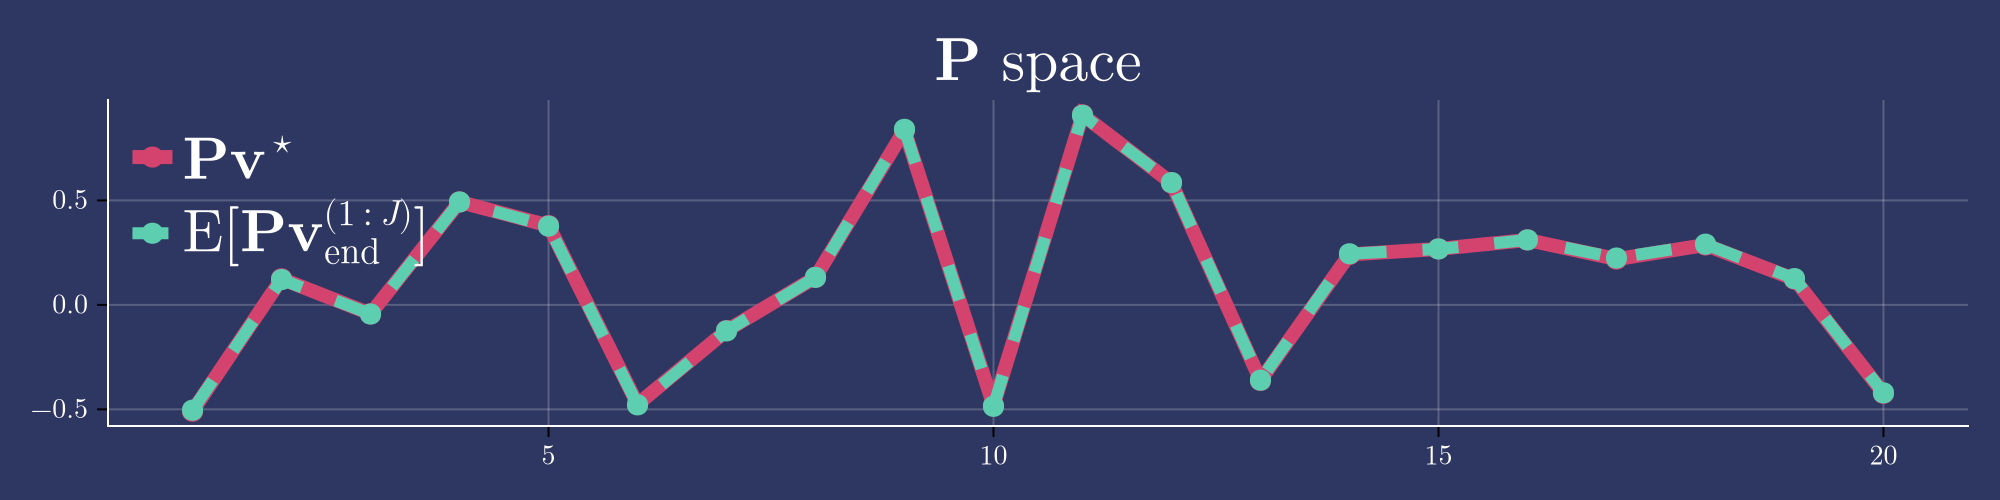

In [27]:
fig = themed_figure(; dark=true, size=(1000, 250)) do fig
    ax1 = Axis(fig[1, 1],
        title     = L"𝐏 \text{ space}",
        titlesize = 30,
    )

    scatterlines!(ax1, P*prob.v_star;
        linewidth   = 7,
        markersize  = 15,
        label       = L"\textbf{Pv}^\star",
        color       = colors[2],
    )

    scatterlines!(ax1, P*μ;
        linewidth   = 6,
        linestyle   = :dash,
        markersize  = 15,
        label       = L"\text{E}[\textbf{Pv}_\text{end}^{(1:J)}]",
        color       = colors[4],
    )
    axislegend(ax1; position=:lt, framevisible=false, labelsize=30)

    fig   
end

As we can see, the quantities now match, confirming our linear theory!